Mortgage Approvals Prediction Model
Objective

The objective of this notebook is to predict Mortgage Approvals using UK macroeconomic and retail banking variables. Feature engineering and normalization are performed before model training, and four regression models are compared: Linear Regression, Random Forest and  XGBoost.

**Import Libraries**

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import statsmodels.api as sm
from xgboost import XGBRegressor

pd.set_option("display.max_columns", None)

**Load the Dataset**

In [33]:
df = pd.read_csv("Final_DS.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Net_Consumer_Credit,Credit_Card_Lending,Consumer_Credit
0,2008-01-01,2008,January,5.50,2.2,5.2,65.6,0.4,33417,224159,71326,288,183,105
1,2008-02-01,2008,February,5.25,2.5,5.2,65.0,0.4,31492,226772,71064,1200,363,837
2,2008-03-01,2008,March,5.25,2.5,5.3,64.5,0.4,32823,227769,60454,432,319,113
3,2008-04-01,2008,April,5.00,3.0,5.2,64.7,-0.5,31895,233766,57134,514,179,335
4,2008-05-01,2008,May,5.00,3.3,5.4,65.1,-0.5,32210,237820,40546,370,752,-382


**Feature Engineering**


In [34]:
# Create lag features
df["Mortgage_Lag1"] = df["Mortgage_Approvals"].shift(1)
df["ConsumerCredit_Lag1"] = df["Consumer_Credit"].shift(1)

# Remove rows with missing lag values
df_model = df.dropna().reset_index(drop=True)

# Display the first five rows
df_model.head()



,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Net_Consumer_Credit,Credit_Card_Lending,Consumer_Credit,Mortgage_Lag1,ConsumerCredit_Lag1
0,2008-02-01,2008,February,5.25,2.5,5.2,65.0,0.4,31492,226772,71064,1200,363,837,71326.0,105.0
1,2008-03-01,2008,March,5.25,2.5,5.3,64.5,0.4,32823,227769,60454,432,319,113,71064.0,837.0
2,2008-04-01,2008,April,5.00,3.0,5.2,64.7,-0.5,31895,233766,57134,514,179,335,60454.0,113.0
3,2008-05-01,2008,May,5.00,3.3,5.4,65.1,-0.5,32210,237820,40546,370,752,-382,57134.0,335.0
4,2008-06-01,2008,June,5.00,3.8,5.5,64.2,-0.5,33348,241184,35391,81,465,-384,40546.0,-382.0


**Feature Selection**

In [35]:
features = [
    "Bank_Rate",
    "CPI",
    "GDP_Growth",
    "Unemployment_Rate",
    "Mortgage_Lag1",
    "ConsumerCredit_Lag1"
]

# Create modelling dataframe and remove rows with missing lag values
df_model = df[features + ["Mortgage_Approvals"]].dropna().reset_index(drop=True)

X = df_model[features]
y = df_model["Mortgage_Approvals"]

print(X.shape)
print(y.shape)

(215, 6)
(215,)


**Correlation Analysis**

In [ ]:
# Correlation matrix
corr_matrix = df_model[features + ["Mortgage_Approvals"]].corr()

# Display correlation with the target variable
mortgage_corr = corr_matrix["Mortgage_Approvals"].sort_values(ascending=False)

mortgage_corr

Mortgage_Approvals     1.000000
Mortgage_Lag1          0.915999
GDP_Growth             0.499815
ConsumerCredit_Lag1    0.313961
Bank_Rate             -0.250156
CPI                   -0.333890
Unemployment_Rate     -0.365782
Name: Mortgage_Approvals, dtype: float64

**Multicollinearity Analysis (VIF)**

In [37]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data

,Feature,VIF
4,Mortgage_Lag1,12.722148
3,Unemployment_Rate,9.186594
1,CPI,3.179573
5,ConsumerCredit_Lag1,1.948112
0,Bank_Rate,1.936683
2,GDP_Growth,1.242971


**Chronological train/test split**

In [ ]:
split = int(len(df_model) * 0.8)

train = df_model.iloc[:split]
test = df_model.iloc[split:]

X_train = train[features]
X_test = test[features]

y_train = train["Mortgage_Approvals"]
y_test = test["Mortgage_Approvals"]

print(X_train.shape, X_test.shape)

(172, 6) (43, 6)


**Standardize the features**

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

(172, 6) (43, 6)


**Linear Regression Model**

In [40]:
from sklearn.linear_model import LinearRegression

# Train the Linear Regression model
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


**Linear Regression Evaluation**

In [41]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Results")
print("R² Score :", round(lr_r2, 4))
print("MAE      :", round(lr_mae, 2))
print("RMSE     :", round(lr_rmse, 2))

Linear Regression Results
R² Score : 0.3967
MAE      : 5715.48
RMSE     : 6425.2


**Linear Regression Coefficients**

In [55]:
# Linear Regression Coefficients

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
4,Mortgage_Lag1,10686.319954
2,GDP_Growth,2914.465770
5,ConsumerCredit_Lag1,-1307.850767
1,CPI,-1328.497061
0,Bank_Rate,-1558.717448
3,Unemployment_Rate,-1844.970214


**Ordinary Least Squares (OLS) Regression**

In [42]:
import statsmodels.api as sm

# Add intercept term
X_train_sm = sm.add_constant(X_train_scaled)

# Fit OLS model
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Display statistical summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:     Mortgage_Approvals   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     249.0
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           5.72e-80
Time:                        04:13:21   Log-Likelihood:                -1689.8
No. Observations:                 172   AIC:                             3394.
Df Residuals:                     165   BIC:                             3416.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.062e+04    348.186    174.097      0.0

**Actual vs Predicted Mortgage Approvals**

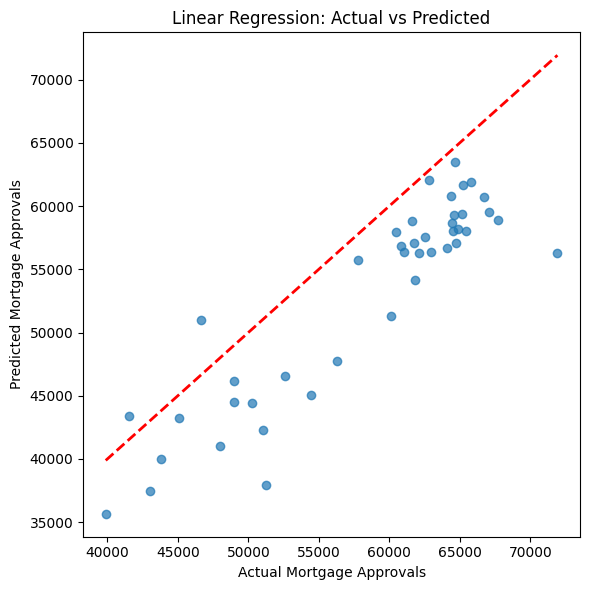

In [43]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr, alpha=0.7)

# 45-degree reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Mortgage Approvals")
plt.ylabel("Predicted Mortgage Approvals")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

**Residual Analysis**

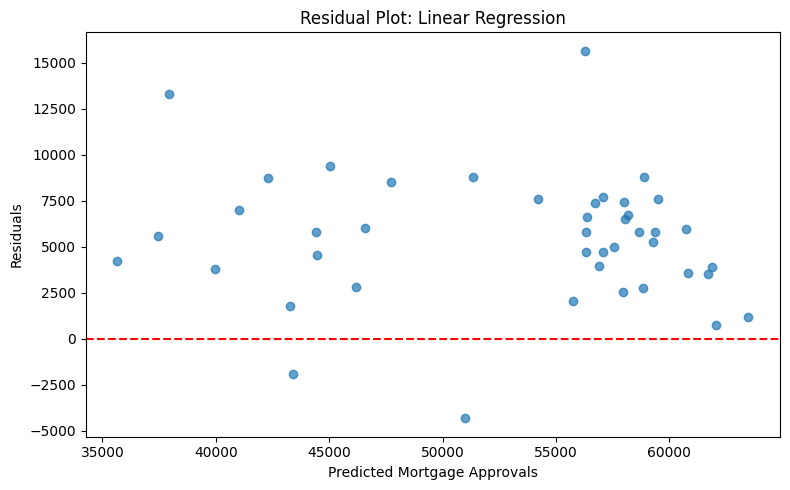

In [44]:
# Calculate residuals
residuals = y_test - y_pred_lr

plt.figure(figsize=(8,5))

plt.scatter(y_pred_lr, residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Mortgage Approvals")
plt.ylabel("Residuals")
plt.title("Residual Plot: Linear Regression")
plt.tight_layout()
plt.show()

**Random Forest Regression**

In [45]:
from sklearn.ensemble import RandomForestRegressor

# Train the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Generate predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


**Random Forest Feature Importance**

In [59]:
# Random Forest Feature Importance

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

rf_importance

,Feature,Importance
4,Mortgage_Lag1,0.824739
2,GDP_Growth,0.087982
3,Unemployment_Rate,0.052467
5,ConsumerCredit_Lag1,0.015066
1,CPI,0.011305
0,Bank_Rate,0.008441


**Random Forest Evaluation**

In [46]:
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Results")
print("R² Score :", round(rf_r2, 4))
print("MAE      :", round(rf_mae, 2))
print("RMSE     :", round(rf_rmse, 2))

Random Forest Results
R² Score : 0.7326
MAE      : 3120.69
RMSE     : 4277.38


**Actual vs Predicted Mortgage Approvals**

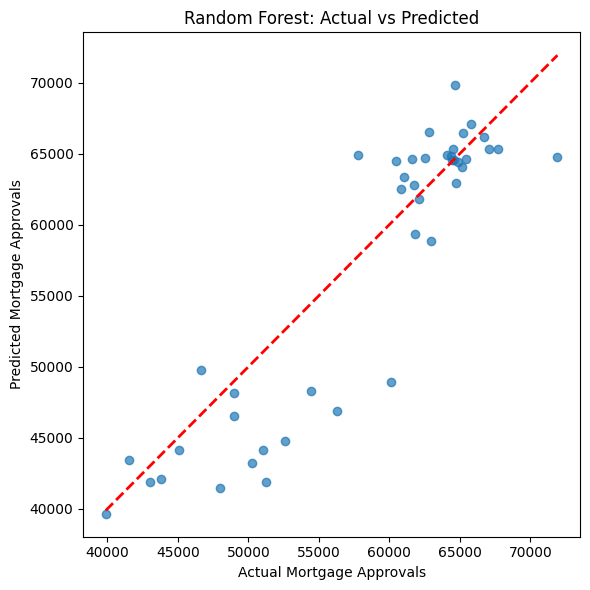

In [47]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.7)

# 45-degree reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Mortgage Approvals")
plt.ylabel("Predicted Mortgage Approvals")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.show()

**Residual Analysis**

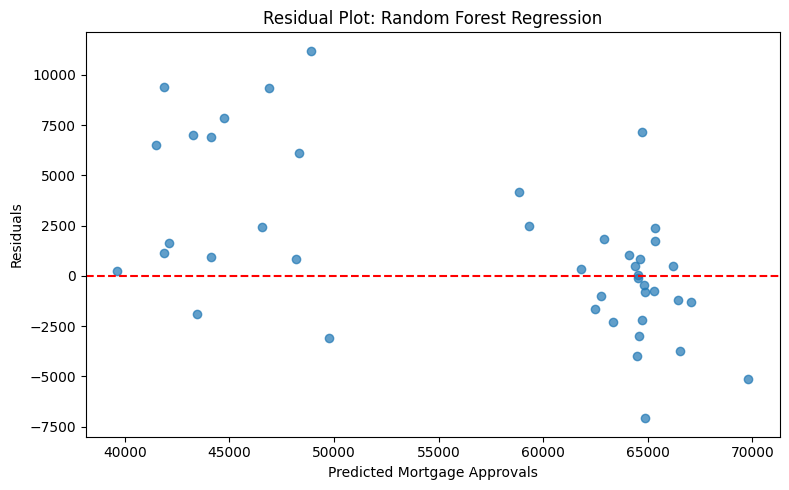

In [48]:
# Calculate residuals
rf_residuals = y_test - y_pred_rf

plt.figure(figsize=(8,5))

plt.scatter(y_pred_rf, rf_residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Mortgage Approvals")
plt.ylabel("Residuals")
plt.title("Residual Plot: Random Forest Regression")
plt.tight_layout()
plt.show()

**XGBoost Regression**

In [49]:
from xgboost import XGBRegressor

# Train the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Generate predictions
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


**XGBoost Feature Importance**

In [58]:
# XGBoost Feature Importance

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(by="Importance", ascending=False)

xgb_importance

,Feature,Importance
4,Mortgage_Lag1,0.462520
2,GDP_Growth,0.169786
3,Unemployment_Rate,0.166057
0,Bank_Rate,0.122566
1,CPI,0.043919
5,ConsumerCredit_Lag1,0.035151


**XGBoost Evaluation**

In [50]:
xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost Results")
print("R² Score :", round(xgb_r2, 4))
print("MAE      :", round(xgb_mae, 2))
print("RMSE     :", round(xgb_rmse, 2))

XGBoost Results
R² Score : 0.7778
MAE      : 3023.51
RMSE     : 3899.16


**Actual vs Predicted Mortgage Approvals**

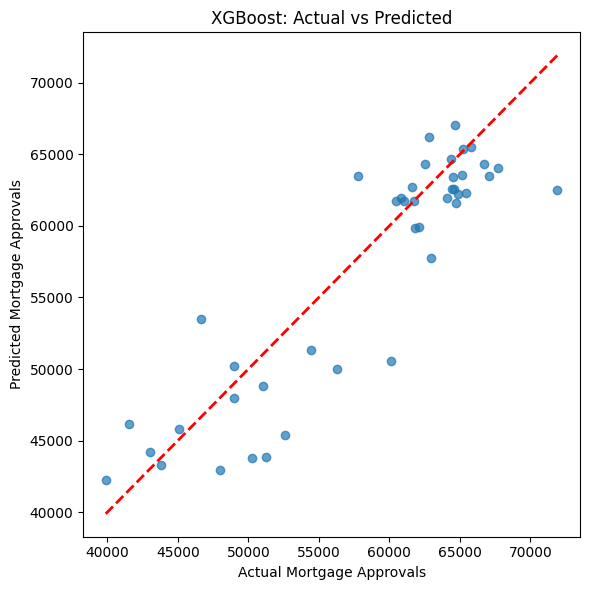

In [51]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_xgb, alpha=0.7)

# 45-degree reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Mortgage Approvals")
plt.ylabel("Predicted Mortgage Approvals")
plt.title("XGBoost: Actual vs Predicted")
plt.tight_layout()
plt.show()

**Residual Analysis**

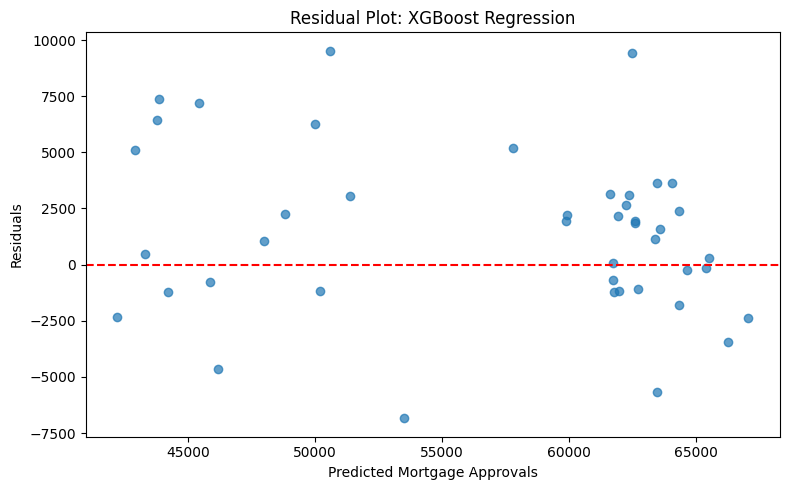

In [52]:
# Calculate residuals
xgb_residuals = y_test - y_pred_xgb

plt.figure(figsize=(8,5))

plt.scatter(y_pred_xgb, xgb_residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Mortgage Approvals")
plt.ylabel("Residuals")
plt.title("Residual Plot: XGBoost Regression")
plt.tight_layout()
plt.show()

**Model Comparison**

In [53]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "R²": [lr_r2, rf_r2, xgb_r2],
    "MAE": [lr_mae, rf_mae, xgb_mae],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse]
})

comparison = comparison.sort_values(by="R²", ascending=False)

comparison

,Model,R²,MAE,RMSE
2,XGBoost,0.777808,3023.510254,3899.161064
1,Random Forest,0.732612,3120.689804,4277.383230
0,Linear Regression,0.396664,5715.484379,6425.201134


**Model Comparison Visualization**

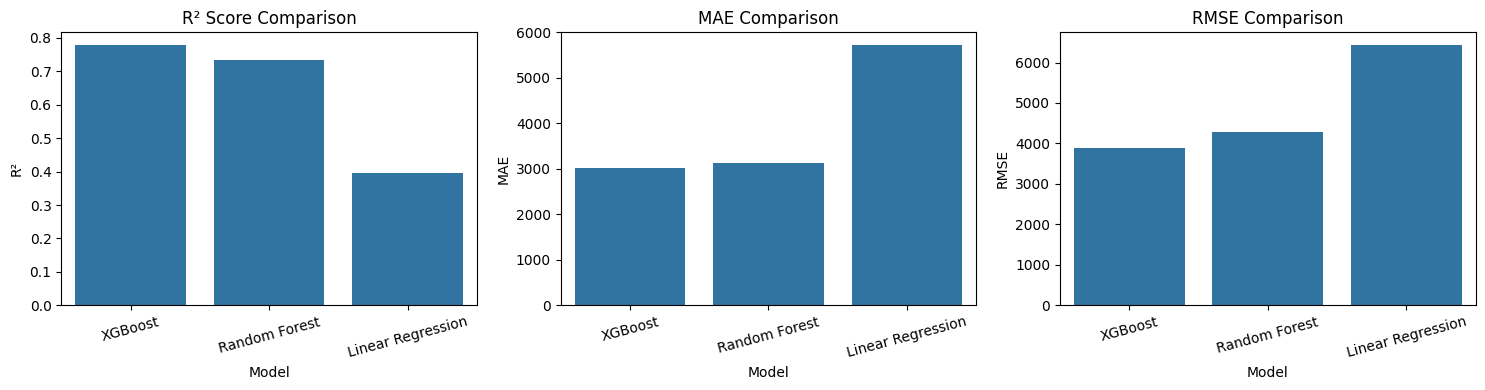

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# R²
sns.barplot(
    data=comparison,
    x="Model",
    y="R²",
    ax=axes[0]
)
axes[0].set_title("R² Score Comparison")
axes[0].tick_params(axis="x", rotation=15)

# MAE
sns.barplot(
    data=comparison,
    x="Model",
    y="MAE",
    ax=axes[1]
)
axes[1].set_title("MAE Comparison")
axes[1].tick_params(axis="x", rotation=15)

# RMSE
sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE",
    ax=axes[2]
)
axes[2].set_title("RMSE Comparison")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()